## Analyze *ex vivo* results

At the top of this notebook, let's carefully look at passing rate:
- By batch, by box, by serial dilution
- also can look at other information from the log file from Rafael
- basically a careful look and clean
- I could also write the cleaned results to an output table and make some diagnostic figures

In [97]:
import os
import re
import shutil
import datetime
import pandas as pd
pd.options.mode.chained_assignment = None 
import seaborn as sns
import scipy.stats as ss

from dataclasses import dataclass

import statsmodels.formula.api as smf
import numpy as np
import missingno

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

In [2]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [3]:
DIR_IC50DATA = "../ic50data/"
DIR_FIGS = "../figures/fig4"
os.makedirs(DIR_FIGS, exist_ok=True)
save_results = True

In [4]:
W = 3.4 # roughly width of one column

In [5]:
P = lambda n, N: f"{n} ({100*n/N:.2f}%) of {N}"

## Load IC50 data
- A lot of work needed cleaning the IC50 data, I think

In [6]:
# Load the log data
df_log = pd.read_csv(f"{DIR_IC50DATA}/Kaoma_Sample_log_april2026.csv", dtype={"sample_id": str})
df_log = df_log[["sample_id", "batch", "boxes", "sample_parasitemia", "difference_time", "ic50_dilutions"]] # restrict investigation to a few key columns

In [7]:
# Load and clean the IC50 data
df_ic50 = pd.read_csv(f"{DIR_IC50DATA}/results/ic50.csv", dtype={"sample_id": str})

# Batch from the field
df_ic50['batch'] = [int(re.match("evIC50_([0-9]{1,2})", plate).group(1)) for plate in df_ic50['plate']]
#df_ic50["drug"] = df_ic50["drug"].map({"dha": "DHA", "lum": "Lumefantrine"})

In [8]:
df_ic50 = pd.merge(
    left=df_ic50,
    right=df_log,
    on=['sample_id', 'batch'],
    validate='m:1'
)

#### Quality control

In [9]:
# Current performance
pd.crosstab(df_ic50["drug"],
            df_ic50["status"],
            margins='All'
           )

status,fail,pass,All
drug,,,
dha,71,123,194
lum,65,129,194
All,136,252,388


In [10]:
# Big improvement by switching boxes
pd.crosstab(df_ic50["boxes"],
            df_ic50["status"],
            margins='All'
           )

status,fail,pass,All
boxes,,,
large,80,62,142
small,56,190,246
All,136,252,388


In [11]:
190/246, 62/142

(0.7723577235772358, 0.43661971830985913)

In [12]:
pd.crosstab(df_ic50["ic50_dilutions"],
            df_ic50["status"],
            margins='All'
           )

status,fail,pass,All
ic50_dilutions,,,
1/3,88,102,190
1/4,48,150,198
All,136,252,388


In [13]:
pd.crosstab(
    pd.cut(df_ic50.difference_time, bins=4),
    df_ic50['status']
)

status,fail,pass
difference_time,,
"(14.3, 22.75]",62,136
"(22.75, 31.167]",64,98
"(31.167, 39.583]",0,6
"(39.583, 48.0]",10,12


- Those exceeding 48h do quite bad

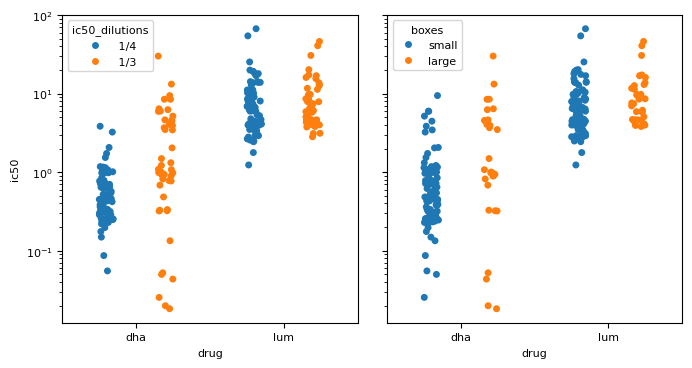

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
fig.subplots_adjust(wspace=0.1)

ax = axes[0]
sns.stripplot(
    x="drug",
    y="ic50",
    hue="ic50_dilutions",
    dodge=True,
    data=df_ic50.query("status == 'pass'"),
    ax=ax
)
ax.set_yscale("log")

ax = axes[1]
sns.stripplot(
    x="drug",
    y="ic50",
    hue="boxes",
    dodge=True,
    data=df_ic50.query("status == 'pass'"),
    ax=ax
)
ax.set_yscale("log")

- We probably have to discard the 1/3 dilution data for DHA
- For Lumefantrine, there is no effect
- But we can clearly see more variation for the 1/3 dilutions
- I think that former variation was probably driven by poor assay evaluation
- but I can get them, and look by eye

<Axes: xlabel='drug', ylabel='r2'>

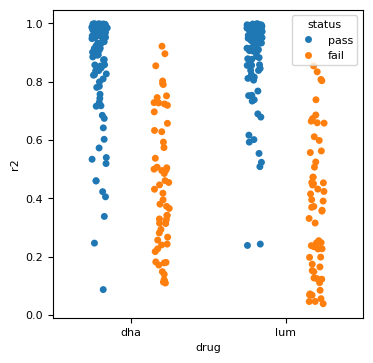

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

sns.stripplot(
    x="drug",
    y="r2",
    hue="status",
    dodge=True,
    data=df_ic50
)

In [16]:
# Review some findings
dir_review = f"{DIR_IC50DATA}/review/high_dha"
os.makedirs(dir_review, exist_ok=True)
for _, row in df_ic50.query("status == 'pass'").query("drug == 'DHA' and ic50 > 2").iterrows():
    plot_name = f"ic50_fit.{row['sample_id']}.dha.pdf"
    shutil.copy2(
        f"{DIR_IC50DATA}/results/{row['plate']}/{plot_name}",
        dir_review
    )

dir_review = f"{DIR_IC50DATA}/review/low_r2"
os.makedirs(dir_review, exist_ok=True)
for _, row in df_ic50.query("status == 'pass'").query("r2 < 0.8").iterrows():
    plot_name = f"ic50_fit.{row['sample_id']}.dha.pdf"
    shutil.copy2(
        f"{DIR_IC50DATA}/results/{row['plate']}/{plot_name}",
        dir_review
    )

- To me, these all look good enough to proceed

Now let's prepare a per-sample table, looking at whether both have passed

``` plate | sample_id | ic50_dha | r2_dha | status_dha | ... ```

In [17]:
df_ic50_wide = pd.pivot_table(
    data=df_ic50,
    index=["plate", "batch", "boxes", "ic50_dilutions", "difference_time", "sample_id", ],
    columns="drug",
    values=["ic50", "r2", "status"],
    aggfunc=lambda x:x
)
df_ic50_wide.columns = [f"{c}_{d}" for c, d in df_ic50_wide.columns]
df_ic50_wide.reset_index(inplace=True)

In [18]:
df_ic50_wide["status_ic50"] = [sum([v == 'pass' for v in [d,l]]) 
                               for d, l in zip(df_ic50_wide['status_dha'], df_ic50_wide['status_lum'])]

In [19]:
pd.crosstab(
    df_ic50_wide['boxes'],
    df_ic50_wide['status_ic50'],
    margins=True
)

status_ic50,0,1,2,All
boxes,,,,
large,36,8,27,71
small,25,6,92,123
All,61,14,119,194


- This is by sample
- we have 27 + 92 passing across all boxes

In [20]:
df_ic50_wide['ic50_dilutions'].unique()

array([' 1/4', ' 1/3'], dtype=object)

In [21]:
_df = df_ic50_wide.query("boxes == 'small'")# and ic50_dilutions == ' 1/4'")
pd.crosstab(
    _df['batch'],
    _df['status_ic50'],
    margins=True
)

status_ic50,0,1,2,All
batch,,,,
6,4,0,20,24
7,3,1,12,16
8,7,1,15,23
9,2,0,13,15
10,5,1,10,16
11,2,2,14,18
12,2,1,8,11
All,25,6,92,123


In [22]:
df_ic50_wide

,plate,batch,boxes,ic50_dilutions,difference_time,sample_id,ic50_dha,ic50_lum,r2_dha,r2_lum,status_dha,status_lum,status_ic50
0,evIC50_10_plate1_23APRIL2026,10,small,1/4,24.300000,8036454,31.682133,0.153556,0.341522,0.234067,fail,fail,0
1,evIC50_10_plate1_23APRIL2026,10,small,1/4,24.916667,8036453,0.246199,67.054354,0.799063,0.940051,pass,pass,2
2,evIC50_10_plate1_23APRIL2026,10,small,1/4,41.083333,8036450,0.440501,3.965930,0.884668,0.903932,pass,pass,2
3,evIC50_10_plate2_23APRIL2026,10,small,1/4,21.733333,8036466,3.242524,13.795576,0.087221,0.733395,pass,pass,2
4,evIC50_10_plate2_23APRIL2026,10,small,1/4,21.916667,8036464,0.620053,52.190993,0.422807,0.084774,pass,fail,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,evIC50_9_plate4_22APRIL2026,9,small,1/4,20.433333,8036438,1.732389,4.219996,0.907693,0.592675,pass,pass,2
190,evIC50_9_plate5_22APRIL2026,9,small,1/4,17.583333,8036446,0.286760,6.903964,0.784133,0.959351,pass,pass,2
191,evIC50_9_plate5_22APRIL2026,9,small,1/4,17.983333,8036445,249.996746,0.187002,0.226725,0.124865,fail,fail,0
192,evIC50_9_plate5_22APRIL2026,9,small,1/4,18.100000,8036444,0.432999,4.119532,0.991586,0.967843,pass,pass,2


In [23]:
df_ic50_wide

,plate,batch,boxes,ic50_dilutions,difference_time,sample_id,ic50_dha,ic50_lum,r2_dha,r2_lum,status_dha,status_lum,status_ic50
0,evIC50_10_plate1_23APRIL2026,10,small,1/4,24.300000,8036454,31.682133,0.153556,0.341522,0.234067,fail,fail,0
1,evIC50_10_plate1_23APRIL2026,10,small,1/4,24.916667,8036453,0.246199,67.054354,0.799063,0.940051,pass,pass,2
2,evIC50_10_plate1_23APRIL2026,10,small,1/4,41.083333,8036450,0.440501,3.965930,0.884668,0.903932,pass,pass,2
3,evIC50_10_plate2_23APRIL2026,10,small,1/4,21.733333,8036466,3.242524,13.795576,0.087221,0.733395,pass,pass,2
4,evIC50_10_plate2_23APRIL2026,10,small,1/4,21.916667,8036464,0.620053,52.190993,0.422807,0.084774,pass,fail,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,evIC50_9_plate4_22APRIL2026,9,small,1/4,20.433333,8036438,1.732389,4.219996,0.907693,0.592675,pass,pass,2
190,evIC50_9_plate5_22APRIL2026,9,small,1/4,17.583333,8036446,0.286760,6.903964,0.784133,0.959351,pass,pass,2
191,evIC50_9_plate5_22APRIL2026,9,small,1/4,17.983333,8036445,249.996746,0.187002,0.226725,0.124865,fail,fail,0
192,evIC50_9_plate5_22APRIL2026,9,small,1/4,18.100000,8036444,0.432999,4.119532,0.991586,0.967843,pass,pass,2


<Axes: >

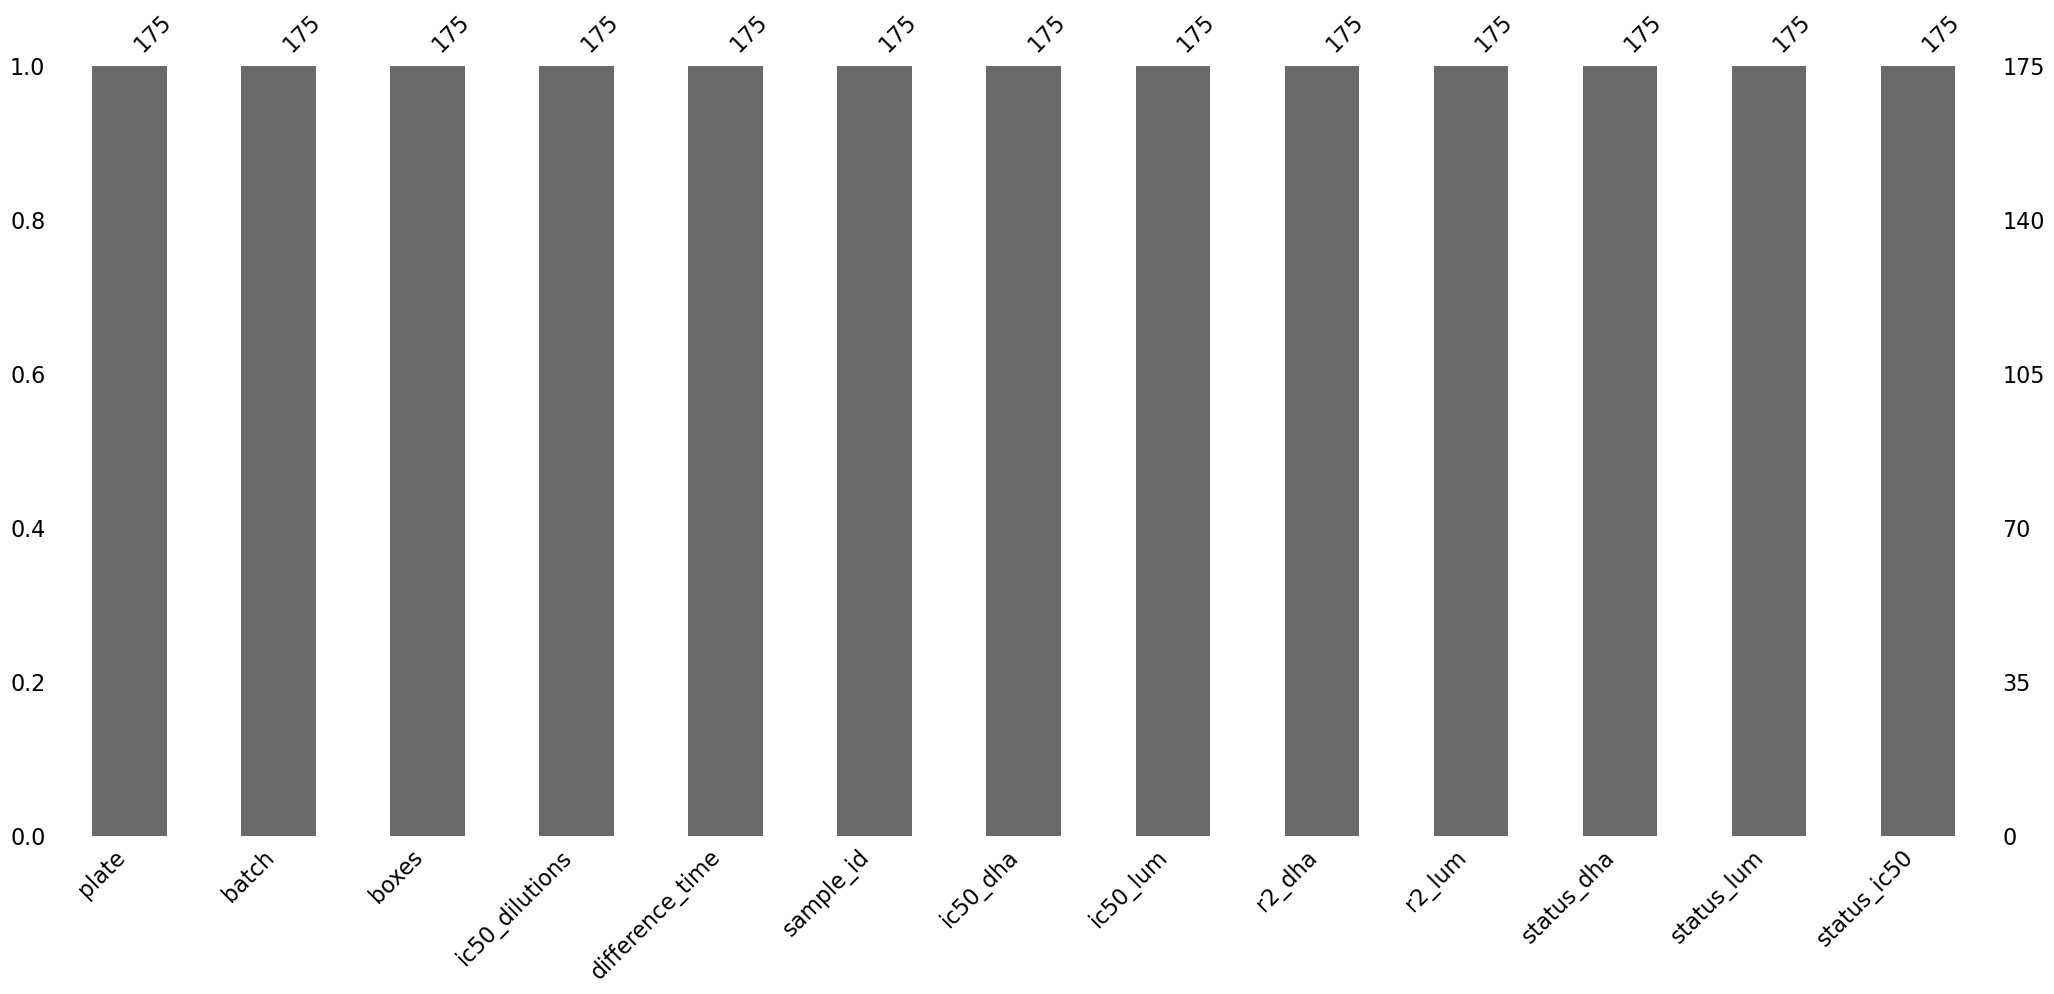

In [24]:
missingno.bar(df_ic50_wide.dropna())

Text(0, 0.5, 'DHA IC50 (nm)')

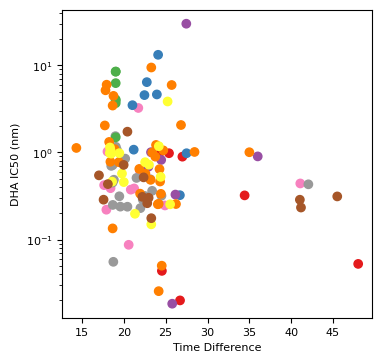

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(
    x="difference_time",
    y="ic50_dha",
    c="batch",
    cmap='Set1',
    data=df_ic50_wide.query("status_dha == 'pass'")
)
ax.set_yscale('log')
ax.set_xlabel("Time Difference") # not much here either
ax.set_ylabel("DHA IC50 (nm)")

- The variance in the data looks not to be explained by technical factors

In [26]:
if save_results:
    df_ic50_wide.to_csv(f"{DIR_FIGS}/ceadriz.ic50_wide.csv", index=False)

In [91]:
108/188

0.574468085106383

## Merge with other CEADRIZ data
- Then filter to analysis set

In [48]:
df_day3 = (
    pd.read_csv(f"{DIR_FIGS}/ceadriz.merged.csv", dtype={"sample_id": str})
    .query("status != 'not_enrolled'")
) # should I get the final table?

In [49]:
df_day3.shape # 188 patients enrolled

(188, 34)

In [56]:
df_merged = pd.merge(
    left=df_day3,
    right=df_ic50_wide,
    on='sample_id',
    how='left',
    validate='1:1',
    #suffixes=("_ic50", "_seq")
)
df_merged.sample_id.duplicated().sum()
df_merged
#df_use = df_merged.query("day_0_seqdone and status_ic50 == 'pass'")

,collection_date,collection_time,village,age,sex,fever,day3_dbs_collected,treatment_history,sample_id,infection_rate,...,boxes,ic50_dilutions,difference_time,ic50_dha,ic50_lum,r2_dha,r2_lum,status_dha,status_lum,status_ic50
0,2026-04-02,_,folkland,17.0,F,Yes,Yes,no,8036219,1.33,...,large,1/3,48.000000,9.665054,NaN,0.148675,NaN,fail,fail,0.0
1,2026-04-02,_,chilombo,20.0,F,Yes,Yes,no,8036220,0.50,...,large,1/3,48.000000,NaN,972.996740,NaN,0.472158,fail,fail,0.0
2,2026-04-02,_,mulamba,1.0,F,Yes,No,no,8036221,0.33,...,large,1/3,48.000000,249.999601,4.867292,0.394932,0.506889,fail,fail,0.0
3,2026-04-02,_,mahilo,2.0,M,Yes,Yes,no,8036222,11.06,...,large,1/3,48.000000,0.052484,3.977785,0.958053,0.958824,pass,pass,2.0
4,2026-04-02,_,mahilo,10.0,M,Yes,Yes,no,8036223,1.46,...,large,1/3,48.000000,249.999617,356.799285,0.256913,0.331000,fail,fail,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,2026-04-22,16:37 Hrs,mungongo,11.0,F,No,Yes,no,8033807,0.20,...,small,1/4,19.050000,1.161785,5.394855,0.962531,0.978088,pass,pass,2.0
184,2026-04-22,16:41 Hrs,mungongo,16.0,M,No,Yes,no,8033808,0.18,...,small,1/4,18.983333,0.010000,17.979843,0.895581,0.940381,fail,pass,1.0
185,2026-04-22,16:42 Hrs,folkland,10.0,F,No,No,no,8033809,0.12,...,small,1/4,18.966667,NaN,237.544880,NaN,0.072489,fail,fail,0.0
186,2026-04-22,16:51 Hrs,mulamba,12.0,F,No,No,no,8033811,1.00,...,small,1/4,18.816667,0.485984,2.444854,0.572640,0.972002,pass,pass,2.0


In [60]:
pd.crosstab(
    df_merged["day3_pos"],
    df_merged["status_dha"],
)

status_dha,fail,pass
day3_pos,,
False,32,49
True,3,17


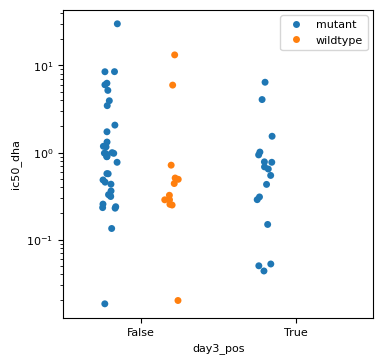

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

sns.stripplot(
    x="day3_pos",
    y="ic50_dha",
    hue="day0_a724_mutant",
    dodge=True,
    data=df_merged.query("status_dha == 'pass'"),
    ax=ax
)
ax.legend(bbox_to_anchor=(1, 1))
ax.set_yscale("log")

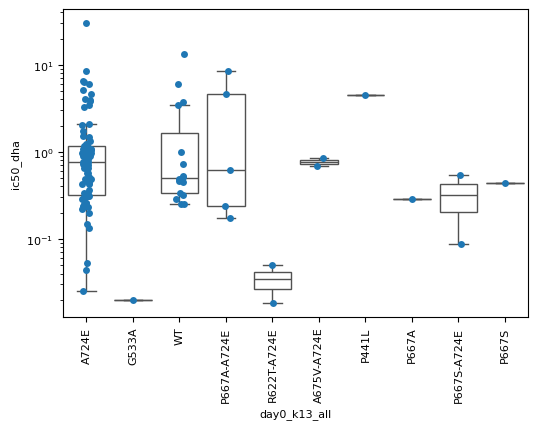

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

sns.stripplot(
    x="day0_k13_all",
    y="ic50_dha",
    #hue="day3_pos",
    dodge=True,
    data=df_merged.query("status_dha == 'pass'"),
    ax=ax
)
sns.boxplot(
    x="day0_k13_all",
    y="ic50_dha",
    #hue="day3_pos",
    boxprops=dict(facecolor='none'),
    showfliers=False,
    dodge=True,
    data=df_merged.query("status_dha == 'pass'"),
    ax=ax
)
ax.tick_params(rotation=90, axis='x')
ax.set_yscale("log")

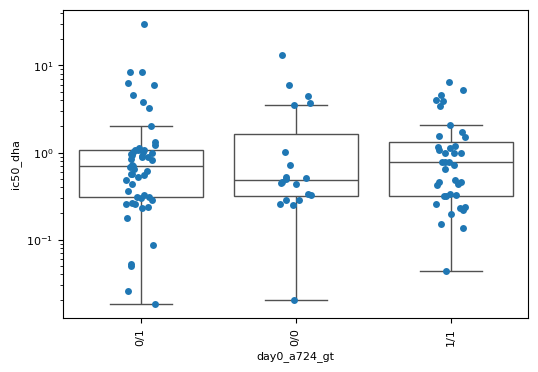

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

sns.stripplot(
    x="day0_a724_gt",
    y="ic50_dha",
    #hue="day3_pos",
    dodge=True,
    data=df_merged.query("status_dha == 'pass'"),
    ax=ax
)
sns.boxplot(
    x="day0_a724_gt",
    y="ic50_dha",
    #hue="day3_pos",
    boxprops=dict(facecolor='none'),
    showfliers=False,
    dodge=True,
    data=df_merged.query("status_dha == 'pass'"),
    ax=ax
)
ax.tick_params(rotation=90, axis='x')
ax.set_yscale("log")

In [78]:
a724_cols = [sns.color_palette("Spectral", 10)[0], (1,1,1)][::-1]#['darkorange', 'white']

In [79]:
df_merged.day0_a724_mutant.value_counts()

day0_a724_mutant
mutant      138
wildtype     37
Name: count, dtype: int64

In [80]:
df_use = (df_merged
    .query("status != 'not_enrolled'")
    .query("day0_seqdone and status_ic50 == 2") # data for both drugs

    # Other filtering, none of this had any noticeable effect
    # .query("boxes == 'small'")
    # .query("ic50_dilutions == ' 1/4'")
    # .query("r2_dha > 0.8 and r2_lum > 0.8")
 )
df_use["day0_a724_mutant_plot"] = pd.Categorical(
    df_use["day0_a724_mutant"].map({"wildtype": "724A", "mutant": "724E"}), 
    categories=["724A", "724E"], ordered=True)

In [81]:
df_merged.shape[0]

188

In [82]:
df_use

,collection_date,collection_time,village,age,sex,fever,day3_dbs_collected,treatment_history,sample_id,infection_rate,...,ic50_dilutions,difference_time,ic50_dha,ic50_lum,r2_dha,r2_lum,status_dha,status_lum,status_ic50,day0_a724_mutant_plot
3,2026-04-02,_,mahilo,2.0,M,Yes,Yes,no,8036222,11.06,...,1/3,48.000000,0.052484,3.977785,0.958053,0.958824,pass,pass,2.0,724E
5,2026-04-04,08:40 Hrs,mahilo,7.0,F,No,Yes,NaN,8036227,0.50,...,1/3,27.000000,0.894395,17.308350,0.981095,0.987012,pass,pass,2.0,724E
6,2026-04-04,08:47 Hrs,mugogo,5.0,M,Yes,Yes,no,8036228,1.00,...,1/3,26.716667,0.019988,5.070105,0.936019,0.904315,pass,pass,2.0,724A
11,2026-04-04,10:57 Hrs,mugogo,1.0,F,Yes,Yes,no,8036238,1.30,...,1/3,24.550000,0.043637,11.335037,0.961131,0.989940,pass,pass,2.0,724E
12,2026-04-04,11:04 Hrs,mulamba,9.0,M,No,Yes,no,8036239,0.30,...,1/3,34.433333,0.321387,5.901180,0.539755,0.855543,pass,pass,2.0,724E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,2026-04-22,15:30 Hrs,mahilo,8.0,F,No,No,no,8033800,1.50,...,1/4,20.166667,0.849358,8.580915,0.983351,0.992834,pass,pass,2.0,724E
182,2026-04-22,16:29 Hrs,mulamba,2.0,M,No,No,no,8033806,0.90,...,1/4,19.183333,1.069005,25.322004,0.974832,0.931350,pass,pass,2.0,724E
183,2026-04-22,16:37 Hrs,mungongo,11.0,F,No,Yes,no,8033807,0.20,...,1/4,19.050000,1.161785,5.394855,0.962531,0.978088,pass,pass,2.0,724E
186,2026-04-22,16:51 Hrs,mulamba,12.0,F,No,No,no,8033811,1.00,...,1/4,18.816667,0.485984,2.444854,0.572640,0.972002,pass,pass,2.0,724E


In [92]:
df_use.shape[0] /188
# for now, all data, but we should look for difference between groups and see if that is an issue
# could use a more sophisticated modelling approach, in that case

0.574468085106383

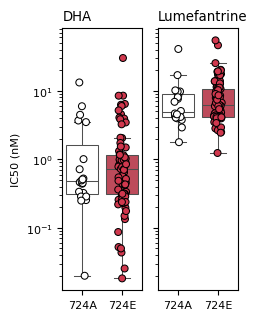

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(W/1.5, W), sharey=True)

ax = axes[0]
sns.boxplot(
    x="day0_a724_mutant_plot",
    y="ic50_dha",
    hue="day0_a724_mutant_plot",
    palette=a724_cols,
    linewidth=0.75,
    data=df_use,
    showfliers=False,
    ax=ax,
    legend=False,
)

# if True:
#     for m, mdf in df_use.groupby("day0_a724_mutant_plot", observed=False):
#         _med = mdf['ic50_dha'].median()
#         _max = mdf['ic50_dha'].max() * 1.4
#         ax.annotate(xy=(m, _max), ha='center', va='bottom',
#                     text=f"{_med:.1f}nM") 

sns.stripplot(
    x="day0_a724_mutant_plot",
    y="ic50_dha",
    hue="day0_a724_mutant_plot",
    palette=a724_cols,
    edgecolor='black', 
    linewidth=0.75,
    data=df_use,
    ax=ax,
    legend=False,
)

ax.set_yscale("log")
ax.set_xlabel("")

ax.set_title("DHA", loc="left")
ax.set_ylabel("IC50 (nM)")

ax = axes[1]
sns.boxplot(
    x="day0_a724_mutant_plot",
    y="ic50_lum",
    hue="day0_a724_mutant_plot",
    palette=a724_cols,
    showfliers=False,
    linewidth=0.75,
    data=df_use,
    ax=ax,
    legend=False,
)

sns.stripplot(
    x="day0_a724_mutant_plot",
    y="ic50_lum",
    hue="day0_a724_mutant_plot",
    palette=a724_cols,
    edgecolor='black', 
    linewidth=0.75,
    data=df_use,
    ax=ax,
    legend=False,
)

ax.set_yscale("log")
ax.set_xlabel("")

ax.set_title("Lumefantrine", loc="left")

# if True:
#     for m, mdf in df_use.groupby("day0_a724_mutant_plot", observed=False):
#         _med = mdf['ic50_lum'].median()
#         _max = mdf['ic50_lum'].min() * 0.6
#         ax.annotate(xy=(m, _max), ha='center', va='bottom',
#                     text=f"{_med:.1f}nM") 


if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.ic50s.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.ic50s.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

In [93]:
def get_number_and_percent(x: np.ndarray, val: str) -> str:
    N = x.shape[0]
    n = (x == val).sum()
    return f"{n} ({100*n/N:.1f})"

In [94]:
def get_median_and_iqrs(x: np.ndarray) -> str:
    med = np.nanmedian(x)
    iqrs = np.nanquantile(x, [0.25, 0.75])
    return f"{med:.1f} ({iqrs[0]:.1f} - {iqrs[1]:.1f})"

In [95]:
class HypothesisTester:
    def __init__(self, groups: str, data: pd.DataFrame) -> None:
        self.groups = groups
        self.data = data
    
    def mannu(self, factor: str) -> float:
        """ Mann-Whitney U Test"""
        values = [list(df[factor]) for _, df in self.data.groupby(self.groups)]
        return ss.mannwhitneyu(*values, nan_policy='omit')

    def chisq(self, factor: str) -> float:
        """ Chi-squared Test"""
        return ss.chi2_contingency(pd.crosstab(self.data[self.groups], self.data[factor]))

    def fisher(self, factor: str) -> float:
        return ss.fisher_exact(pd.crosstab(self.data[self.groups], self.data[factor]))

In [98]:
@dataclass
class UniResult:
    variable: str
    test: str
    pvalue: float

    def __post_init__(self):
        self.pvalue = round(self.pvalue, 3) if isinstance(self.pvalue, float) else self.pvalue

In [104]:
_df_describe = (df_use.groupby("day0_a724_mutant_plot", observed=False)
 .agg(
     N=pd.NamedAgg("ic50_dha", lambda x: len(x)),
     DHA=pd.NamedAgg("ic50_dha", get_median_and_iqrs),
     Lumefantrine=pd.NamedAgg("ic50_lum", get_median_and_iqrs),
 )
).transpose()

In [105]:
tester = HypothesisTester(data=df_use, groups="day0_a724_mutant_plot")
_df_stats = pd.DataFrame(
    [
        UniResult("N", "-", "-"),
        UniResult("DHA", "Mann-Whitney $U$", tester.mannu("ic50_dha").pvalue),
        UniResult("Lumefantrine", "Mann-Whitney $U$", tester.mannu("ic50_lum").pvalue),
    ]
)
_df_stats.set_index('variable', inplace=True)

/var/folders/w7/hc0fpn2s7ll378x1vzz2_pr00000gq/T/ipykernel_26419/1346393228.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values = [list(df[factor]) for _, df in self.data.groupby(self.groups)]


In [108]:
df_ic50_summary = pd.concat([_df_describe, _df_stats], axis=1)

In [109]:
df_ic50_summary

,724A,724E,test,pvalue
N,20,88,-,-
DHA,0.5 (0.3 - 1.6),0.7 (0.3 - 1.1),Mann-Whitney $U$,0.684
Lumefantrine,4.9 (4.1 - 8.9),6.1 (4.2 - 10.8),Mann-Whitney $U$,0.445


In [115]:
if save_results:
    df_ic50_summary.to_excel(f"../tables/stable_ceadriz.ic50summary.xlsx", index=True)
    df_use.to_csv(f"{DIR_FIGS}/ceadriz.ic50_seq.csv", index=False)

## To do
- Look at the complete data
- Will add significance manually